# Mini-Project : Marketing Strategy

## Mini-Project : Data Analysis For Marketing Strategy



## Introduction

In this mini-project, we will perform data analysis to devise a marketing strategy based on various aspects like area analysis, customer analysis, product category analysis, and sales and profit time series.



## 👩‍🏫 👩🏿‍🏫 What You’ll Learn

* How to load and preprocess a dataset.
* Techniques for area analysis to identify key markets.
* Methods for customer analysis to determine high-value customers.
* Strategies for product category analysis to identify top-performing products.
* How to analyze sales and profit trends over time.
* Application of the Pareto Principle to prioritize key drivers of sales and profit.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

## Dataset

The US Superstore Dataset contains the following attributes:

* Row ID: Unique ID for each row.
* Order ID: Unique Order ID for each Customer.
* Order Date: Order Date of the product.
* Ship Date: Shipping Date of the Product.
* Ship Mode: Shipping Mode specified by the Customer.
* Customer ID: Unique ID to identify each Customer.
* Customer Name: Name of the Customer.
* Segment: The segment where the Customer belongs.
* Country: Country of residence of the Customer.
* City: City of residence of the Customer.
* State: State of residence of the Customer.
* Postal Code: Postal Code of every Customer.
* Region: Region where the Customer belongs.
* Product ID: Unique ID of the Product.
* Category: Category of the product ordered.
* Sub-Category: Sub-Category of the product ordered.
* Product Name: Name of the Product.
* Sales: Sales of the Product.
* Quantity: Quantity of the Product.
* Discount: Discount provided.
* Profit: Profit/Loss incurred.


In [4]:
#@title 🔄 Colab & Local Jupyter Folder Switcher (click to expand)

# 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
# 🚨        Change only this 🚨
relative_path = "_datasets" #🚨 any relative path
# 🚨        Change only this 🚨
# 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨

import os

create_if_missing = True      # False = error if folder missing

def in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

def paths_equal(a: str, b: str) -> bool:
    """Portable path equality (no os.path.samepath)."""
    return os.path.normcase(os.path.realpath(a)) == os.path.normcase(os.path.realpath(b))

def resolve_local_base(rel_path: str) -> str:
    pinned = os.getenv("NOTEBOOK_ROOT")
    if pinned:
        return pinned
    cwd = os.path.abspath(os.getcwd())
    rel_name = os.path.basename(os.path.normpath(rel_path))
    base = os.path.dirname(cwd) if rel_name and os.path.basename(cwd) == rel_name else cwd
    os.environ["NOTEBOOK_ROOT"] = base
    return base

def resolve_colab_base(rel_path: str) -> str:
    pinned = os.getenv("COLAB_ROOT")
    if pinned:
        return pinned
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    mydrive = "/content/drive/MyDrive"
    colab_nb = os.path.join(mydrive, "Colab Notebooks")
    base = colab_nb if os.path.isdir(colab_nb) else mydrive
    os.environ["COLAB_ROOT"] = base
    return base

# --- Pick base path ---
if in_colab():
    print("✅ Detected Google Colab")
    base_path = resolve_colab_base(relative_path)
else:
    print("✅ Detected Local Jupyter")
    base_path = resolve_local_base(relative_path)

# --- Build target path ---
if os.path.isabs(relative_path):
    target_path = os.path.abspath(relative_path)
else:
    target_path = os.path.abspath(os.path.join(base_path, relative_path))

current = os.path.abspath(os.getcwd())
rel_name = os.path.basename(os.path.normpath(relative_path))
if rel_name and os.path.basename(current) == rel_name:
    target_path = current

# --- Ensure exists ---
if not os.path.exists(target_path):
    if create_if_missing:
        os.makedirs(target_path, exist_ok=True)
        print(f"📁 Created folder: {target_path}")
    else:
        raise FileNotFoundError(f"❌ Path does not exist: {target_path}")

# --- Change only if needed ---
if paths_equal(current, target_path):
    print(f"📂 Already working in: {current}")
else:
    os.chdir(target_path)
    print(f"📂 Now working in: {os.path.abspath(os.getcwd())}")


✅ Detected Local Jupyter
📂 Now working in: /Users/jayklarin/Documents/__DI/Repositories/di_bootcamp/Colab-Swap/_datasets


In [5]:
df = pd.read_excel('US Superstore data.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Task

First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

* Which states have the most sales?
* What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
* Who is an outstanding customer in New York?
* Are there any differences among states in profitability?
* The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
* What are the Top 20 customers by Sales?
* Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
* Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

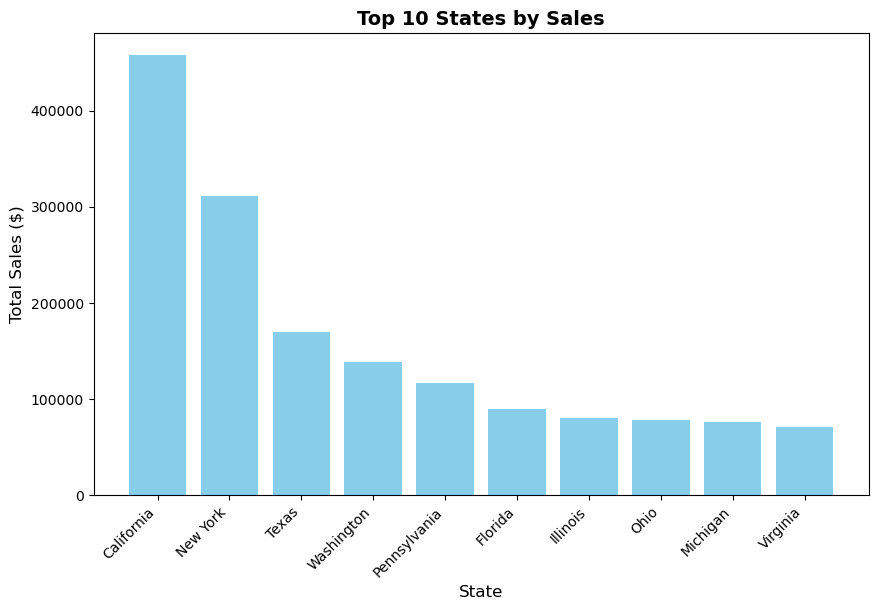

In [7]:
# Which states have the most sales?

# Group into dataframe by state and sum sales
state_sales_df = df.groupby("State")["Sales"].sum().round(2).reset_index()

# Sort descending by total sales
state_sales_df = state_sales_df.sort_values("Sales", ascending=False)

# Grab top 10
state_sales_chart = state_sales_df.head(10)  # top 10

# Plot
plt.figure(figsize=(10,6))
plt.bar(state_sales_chart["State"], state_sales_chart["Sales"], color="skyblue")

# Labels & title
plt.title("Top 10 States by Sales", fontsize=14, fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.show()

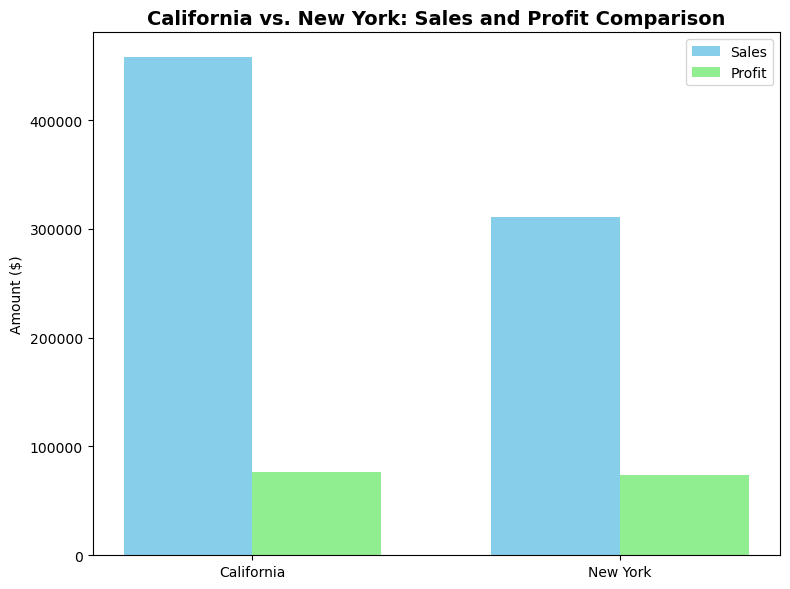

The difference between New York and California in terms of sales is 146811.36
The difference between New York and California in terms of profit is 2342.84


In [8]:
# What is the difference between New York and California
# in terms of sales and profit? (Compare the total sales
# and profit between New York and California.)

# Group into a Series was easier than using the df above
state_sales_series = df.groupby("State")["Sales"].sum()
state_profit_series = df.groupby("State")["Profit"].sum()

# Now you can index by state name
difference_sales = state_sales_series["California"] - state_sales_series["New York"]
difference_profit = state_profit_series["California"] - state_profit_series["New York"]

# Extract sales and profit for the two states
states = ["California", "New York"]
sales_values = [state_sales_series[s] for s in states]
profit_values = [state_profit_series[s] for s in states]

# Create side-by-side bars
x = range(len(states))
width = 0.35

plt.figure(figsize=(8,6))
plt.bar([i - width/2 for i in x], sales_values, width=width, label="Sales", color="skyblue")
plt.bar([i + width/2 for i in x], profit_values, width=width, label="Profit", color="lightgreen")

# Labels & formatting
plt.xticks(x, states)
plt.ylabel("Amount ($)")
plt.title("California vs. New York: Sales and Profit Comparison", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

print(f'The difference between New York and California in terms of sales is {difference_sales.round(2)}')
print(f'The difference between New York and California in terms of profit is {difference_profit.round(2)}')

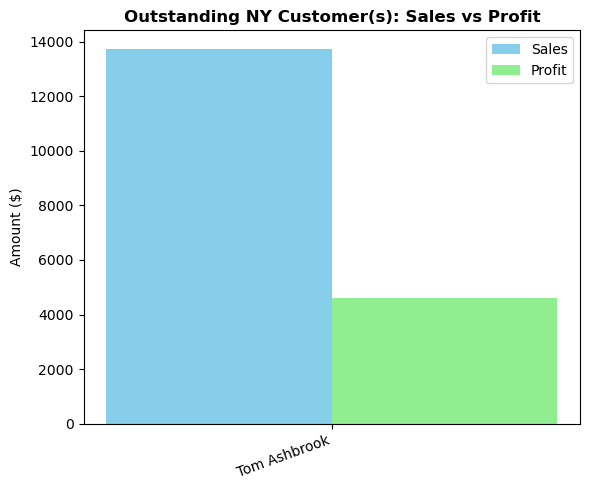

Outstanding customer in New York:
Name: Tom Ashbrook
Total Sales: 13723.50
Total Profit: 4599.21


In [10]:
# Who is an outstanding customer in New York?

# Filter df having only New York
new_york_df = df[df['State']=='New York']
ny_totals_df = (new_york_df
             .groupby(["Customer ID", "Customer Name"])
             [["Sales","Profit"]]
             .sum()
             .reset_index())
# Sort descending by total sales
ny_totals_df = ny_totals_df.sort_values("Sales", ascending=False)

# ny_totals_df['Customer Name'].head(1)  # top 10 customers
top_customer = ny_totals_df.iloc[0]

# For use with Chart
top_k = ny_totals_df.head(1)  # change to 3/5 to compare more
states = top_k["Customer Name"]
sales  = top_k["Sales"]
profit = top_k["Profit"]

x = range(len(top_k))
w = 0.35
plt.figure(figsize=(6,5))
plt.bar([i-w/2 for i in x], sales,  width=w, label="Sales",  color="skyblue")
plt.bar([i+w/2 for i in x], profit, width=w, label="Profit", color="lightgreen")
plt.xticks(list(x), states, rotation=20, ha="right")
plt.ylabel("Amount ($)")
plt.title("Outstanding NY Customer(s): Sales vs Profit", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

print("Outstanding customer in New York:")
print(f"Name: {top_customer['Customer Name']}")
print(f"Total Sales: {top_customer['Sales']:.2f}")
print(f"Total Profit: {top_customer['Profit']:.2f}")

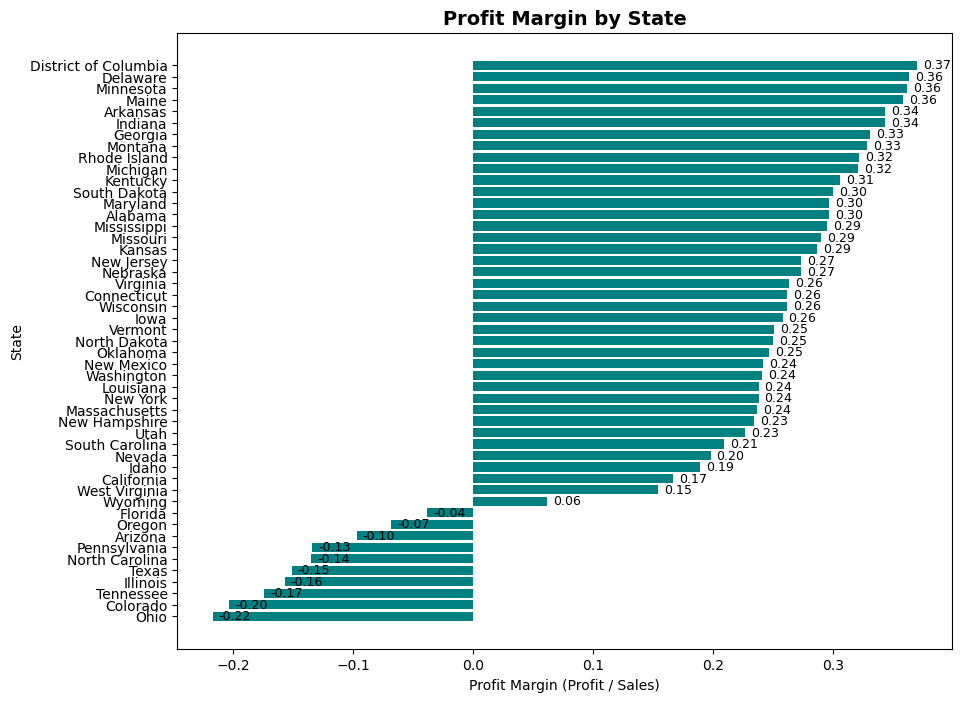

In [11]:
# Are there any differences among states in profitability?
# Group by state and aggregate
state_profit = (df.groupby("State")[["Sales", "Profit"]]
                  .sum()
                  .reset_index())

# Add a profitability metric (profit margin = profit / sales)
state_profit["Profit_Margin"] = (state_profit["Profit"] / state_profit["Sales"]).round(3)

# Sort by profit margin
state_profit = state_profit.sort_values("Profit_Margin", ascending=False)

plt.figure(figsize=(10,8))
plt.barh(state_profit["State"], state_profit["Profit_Margin"], color="teal")
plt.gca().invert_yaxis()  # highest margin at top

plt.title("Profit Margin by State", fontsize=14, fontweight="bold")
plt.xlabel("Profit Margin (Profit / Sales)")
plt.ylabel("State")

# Annotate bars with margin values
for i, v in enumerate(state_profit["Profit_Margin"]):
    plt.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)

plt.show()

# Huge differences
# There are differences in profit margin ranging from 37% to -22%

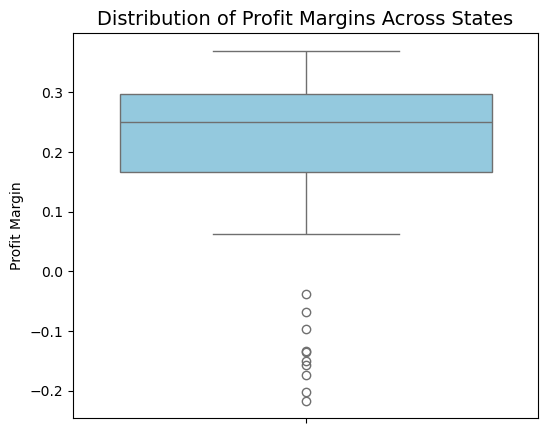

In [12]:
# Let's check the boxplot for outliers
plt.figure(figsize=(6,5))
sns.boxplot(y=state_profit["Profit_Margin"], color="skyblue")

plt.title("Distribution of Profit Margins Across States", fontsize=14)
plt.ylabel("Profit Margin")
plt.show()
# The states with negative profit margins are outliers

The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.) What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)

In [14]:
# Aggregate profit by customer
cust_profit = (df.groupby(["Customer ID","Customer Name"])["Profit"]
                 .sum()
                 .reset_index()
                 .sort_values("Profit", ascending=False))

# Calculate cumulative contribution
cust_profit["Cumulative_Profit"] = cust_profit["Profit"].cumsum()
cust_profit["Cumulative_Pct"] = 100 * cust_profit["Cumulative_Profit"] / cust_profit["Profit"].sum()

# Identify top 20% customers
top_20pct_cutoff = int(len(cust_profit) * 0.2)
top_customers = cust_profit.head(top_20pct_cutoff)

print("Top 20% of customers contribute this much profit:")
print(f"{top_customers['Profit'].sum():.2f} ({top_customers['Profit'].sum()/cust_profit['Profit'].sum()*100:.1f}%)")

Top 20% of customers contribute this much profit:
233201.28 (81.4%)


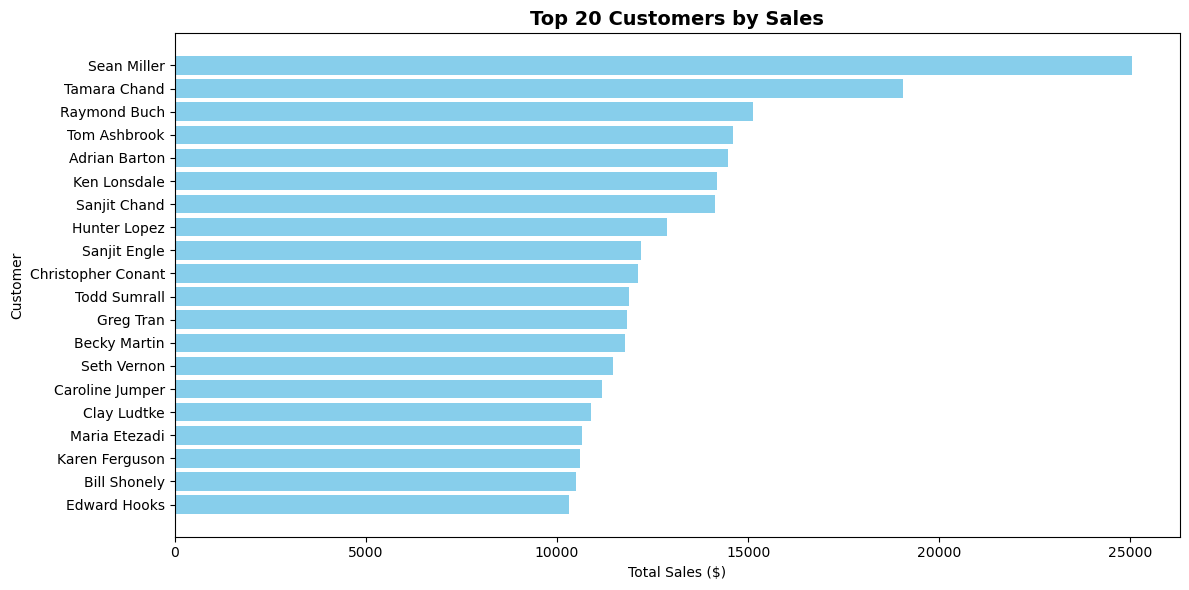

In [15]:
# What are the Top 20 customers by Sales?
# Aggregate profit by customer
customer_sales = (df.groupby(["Customer ID","Customer Name"])["Sales"]
                 .sum()
                 .reset_index()
                 .sort_values("Sales", ascending=False))
top_customers = customer_sales.head(20)

plt.figure(figsize=(12,6))
plt.barh(top_customers["Customer Name"], top_customers["Sales"], color="skyblue")
plt.gca().invert_yaxis()  # top customer at top
plt.title("Top 20 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

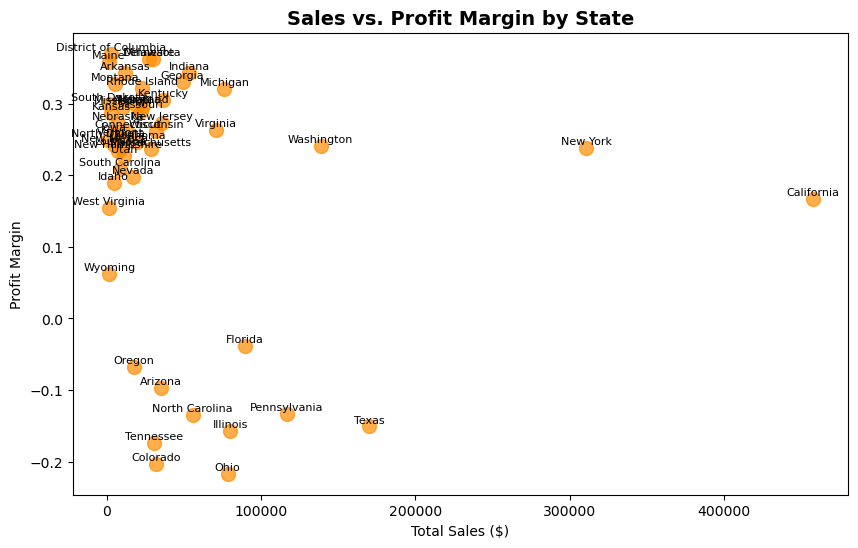

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(state_profit["Sales"], state_profit["Profit_Margin"], s=100, color="darkorange", alpha=0.7)

# Add state labels
for i, row in state_profit.iterrows():
    plt.text(row["Sales"], row["Profit_Margin"]+0.005, row["State"], fontsize=8, ha="center")

plt.title("Sales vs. Profit Margin by State", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin")
plt.show()
# We don't like the thrid quadrant of this chart.  Those are bad states for us

<Figure size 600x500 with 0 Axes>

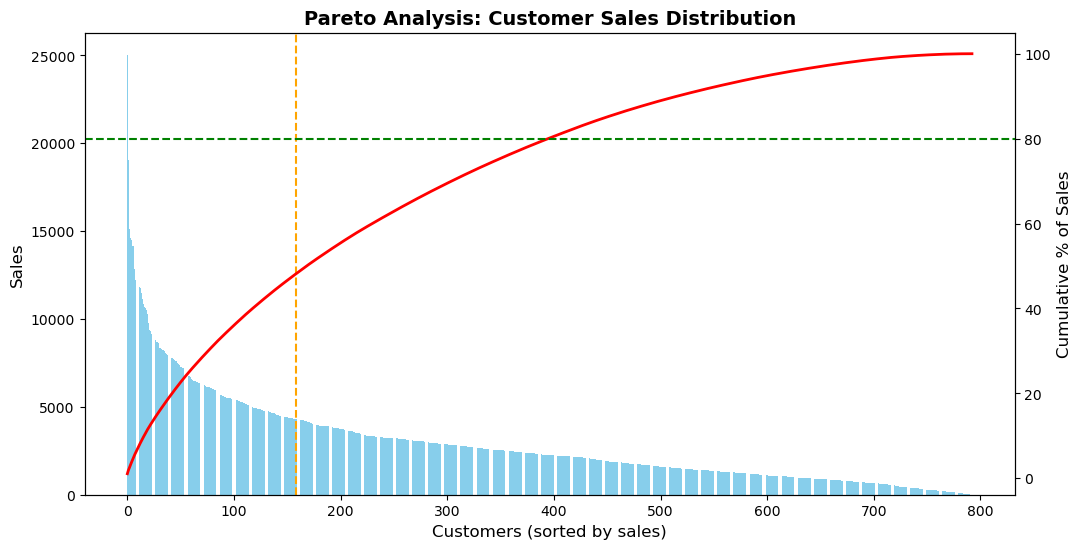

Top 20% of customers contribute 48.1% of sales


In [17]:
# 1. Aggregate and sort
plt.figure(figsize=(6,5))

# A) Reset the index after sorting (clean, preferred)
cust_sales = (df.groupby(["Customer ID","Customer Name"])["Sales"]
                .sum()
                .reset_index()
                .sort_values("Sales", ascending=False)
                .reset_index(drop=True))   # <-- important

cust_sales["Cumulative_Sales"] = cust_sales["Sales"].cumsum()
cust_sales["Cumulative_Pct"]   = 100 * cust_sales["Cumulative_Sales"] / cust_sales["Sales"].sum()


# 3. Plot Pareto chart
fig, ax1 = plt.subplots(figsize=(12,6))

# Blue bars = individual customer sales
ax1.bar(cust_sales.index, cust_sales["Sales"], color="skyblue")
ax1.set_ylabel("Sales", fontsize=12)
ax1.set_xlabel("Customers (sorted by sales)", fontsize=12)

# Red line = cumulative % of sales
ax2 = ax1.twinx()
ax2.plot(cust_sales.index, cust_sales["Cumulative_Pct"], color="red", linewidth=2)
ax2.set_ylabel("Cumulative % of Sales", fontsize=12)

# Reference lines
ax2.axhline(80, color="green", linestyle="--")  # 80% threshold
cutoff = int(len(cust_sales) * 0.2)
ax1.axvline(cutoff, color="orange", linestyle="--")  # top 20% cutoff

plt.title("Pareto Analysis: Customer Sales Distribution", fontsize=14, fontweight="bold")
plt.show()

# Index of cutoff (top 20% customers)
cutoff = int(len(cust_sales) * 0.2)

# Cumulative % at that cutoff
pct_at_20 = cust_sales.loc[cutoff, "Cumulative_Pct"]
print(f"Top 20% of customers contribute {pct_at_20:.1f}% of sales")

# Visually from this chart, 20% of the customers contribute to about 45% of cumulative sales

## Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.
The Pareto principle doesn't track to sales in our dataset, but it toes track to profit.  

Prioritize the highest sales states, such as California, New York, Texas, Washington and Pennsilvania.
* These are high volume states and contribute a lot to the business.  

Prioritize all states with a profit margin of at least 33%
* Though these states may have lower sales volumes, they disporportionally add to the bottom line.
* Run ad campaigns
* Offer high volume customers in these states VIP offers and personalized campaigns.  
* Low volume states with high profit margins should be marketed to agressively

Audit states with profit margin below 5%
* Find out why margins are so low.
* Consider raising prices on low margin items
* Consider closing operations in states with very low and especially negative profit margins.
* Market more agressively to your top 20% of customers in these states.
* Offer them VIP offers, special campaigns, personalized offers.
  

